# Genome-Level Heatmap

This tutorial demonstrates how to visualize genome-scale data using
ComplexHeatmap. Genomic signal data (chromosome windows, numeric and
character matrices, gene labels) is loaded from the bundled dataset
via `load_genome_level_data()`.

The key techniques are:
- Splitting heatmap rows by chromosome using `row_split`
- Adding column annotations based on sample subgroup
- Combining numeric and character heatmaps with row annotations

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## Loading the genome-level data

The bundled dataset contains pre-computed 1MB windows across human
chromosomes with simulated numeric values, character (CNV gain/loss)
values, and sample subgroup labels.

In [2]:
gdata = load_genome_level_data()
print(f"Type: {type(gdata).__name__}")
print(f"Keys: {list(gdata.keys())}")

Type: dict
Keys: ['num_mat', 'char_mat', 'chr', 'chr_level', 'subgroup', 'at', 'labels', 'v']


## Inspecting the data components

The dataset should contain at minimum:
- `num_mat`: numeric matrix (windows x samples)
- `char_mat`: character matrix (CNV calls)
- `chr`: chromosome labels for row splitting
- `chr_level`: ordered chromosome names
- `subgroup`: sample subgroup labels

In [3]:
expected_keys = {"num_mat", "char_mat", "chr", "chr_level", "subgroup"}
actual_keys = set(gdata.keys())
print(f"Has required keys: {expected_keys.issubset(actual_keys)}")

num_mat = gdata["num_mat"]
char_mat = gdata["char_mat"]
chr_vec = gdata["chr"]
chr_level = gdata["chr_level"]
subgroup = gdata["subgroup"]

print(f"num_mat shape: {num_mat.shape}")
print(f"char_mat shape: {char_mat.shape}")
print(f"Unique chromosomes: {len(set(chr_vec))}")
print(f"Subgroups: {np.unique(subgroup) if isinstance(subgroup, np.ndarray) else set(subgroup)}")

Has required keys: True
num_mat shape: (2875, 10)
char_mat shape: (2875, 10)
Unique chromosomes: 22
Subgroups: {'B', 'A'}


## Basic numeric heatmap (no clustering)

Genome-level heatmaps typically disable clustering because the rows
are ordered by genomic position.

In [11]:
ht = Heatmap(
    num_mat,
    name="genome_num",
    cluster_rows=False,
    cluster_columns=False,
)
ht.make_layout()

## Heatmap split by chromosome

By passing `chr_vec` to `row_split`, each chromosome gets its own
slice in the heatmap. The number of slices should match the number
of unique chromosomes.

In [5]:
ht_split = Heatmap(
    num_mat,
    name="genome_split",
    row_split=chr_vec,
    cluster_rows=False,
    cluster_columns=False,
)
ht_split.make_layout()

n_slices = len(ht_split.row_order_list())
n_unique_chr = len(set(chr_vec))
print(f"Row slices: {n_slices}")
print(f"Unique chromosomes: {n_unique_chr}")
print(f"Slices match chromosomes: {n_slices == n_unique_chr}")

Row slices: 22
Unique chromosomes: 22
Slices match chromosomes: True


## Heatmap with chromosome split and drawing

Here we draw the chromosome-split heatmap with a color function and
compact row title style.

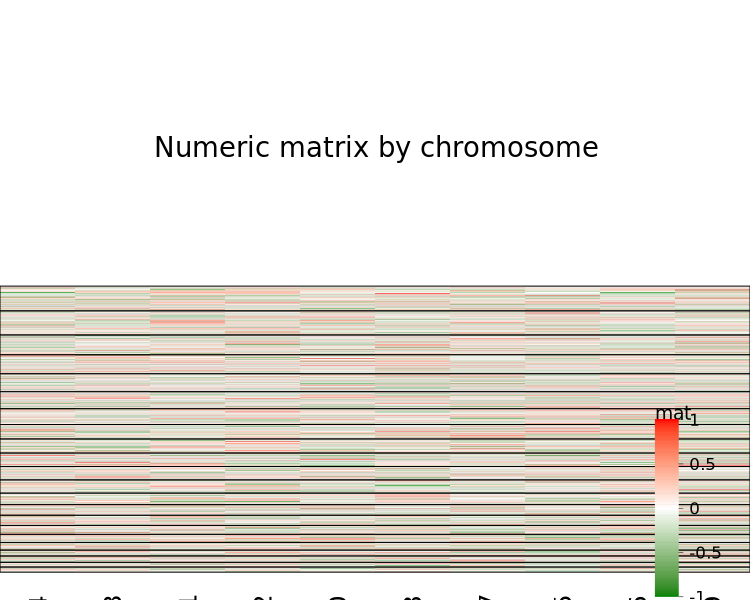

In [6]:
col_fun = color_ramp2([-1, 0, 1], ["green", "white", "red"])

ht_chr = Heatmap(
    num_mat,
    name="mat",
    col=col_fun,
    row_split=chr_vec,
    cluster_rows=False,
    show_column_dend=False,
    show_row_names=False,
    border=True,
    column_title="Numeric matrix by chromosome",
)
ht_chr.draw()

## Adding subgroup annotation

A top annotation showing the sample subgroup helps identify which
columns belong to which experimental group.

In [7]:
subgroup_arr = np.array(subgroup) if isinstance(subgroup, list) else subgroup

ha = HeatmapAnnotation(subgroup=subgroup_arr)

ht_anno = Heatmap(
    num_mat,
    name="genome_anno",
    top_annotation=ha,
    cluster_rows=False,
    cluster_columns=False,
    show_row_names=False,
)
ht_anno.make_layout()
print(f"Construction with annotation: OK")
print(f"nrow={ht_anno.nrow}, ncol={ht_anno.ncol}")

Construction with annotation: OK
nrow=2875, ncol=10


## Combined heatmap with subgroup annotation and chromosome split

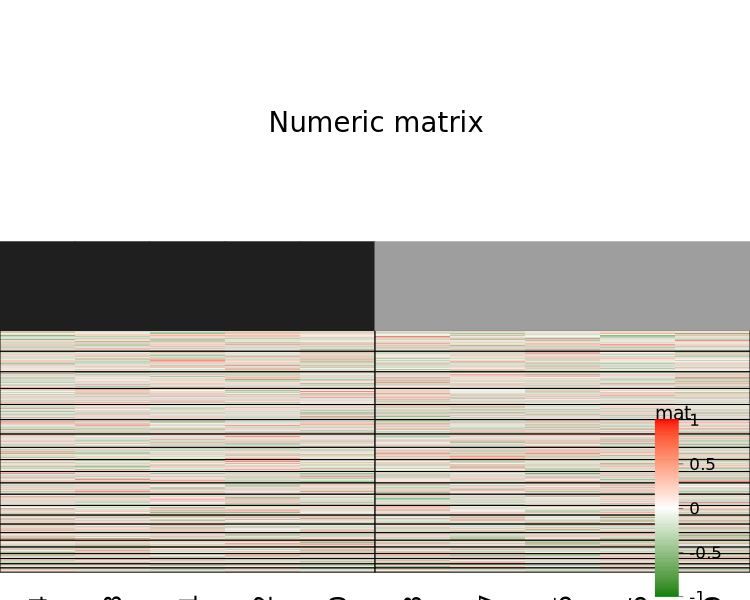

In [8]:
ha_top = HeatmapAnnotation(
    subgroup=subgroup_arr,
    annotation_name_side="left",
)

ht_combined = Heatmap(
    num_mat,
    name="mat",
    col=col_fun,
    row_split=chr_vec,
    cluster_rows=False,
    show_column_dend=False,
    column_split=subgroup_arr,
    top_annotation=ha_top,
    show_row_names=False,
    border=True,
    column_title="Numeric matrix",
)
ht_combined.draw()

## Multi-track genome heatmap

The real power of ComplexHeatmap for genomic data is combining multiple
tracks: a numeric heatmap, a character heatmap (CNV gain/loss), and row
annotations -- all sharing the same row ordering by genomic position.

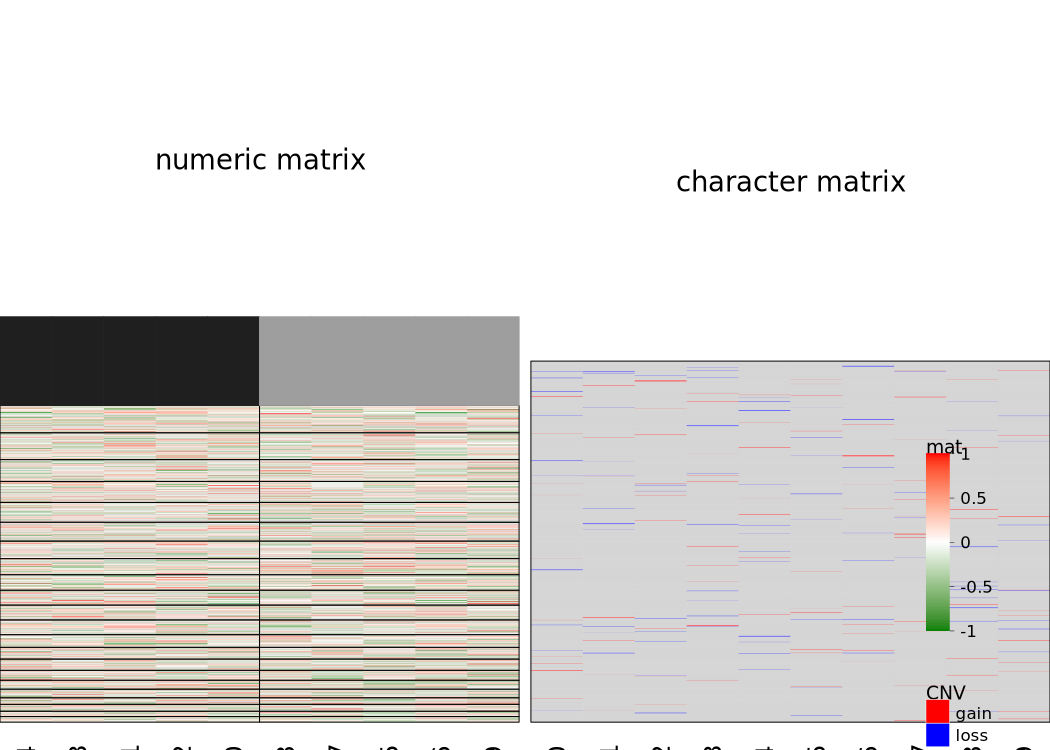

HeatmapList(['mat', 'CNV'], direction='horizontal')

In [9]:
# Numeric heatmap with chromosome splitting
ht_num = Heatmap(
    num_mat,
    name="mat",
    col=col_fun,
    row_split=chr_vec,
    cluster_rows=False,
    show_column_dend=False,
    column_split=subgroup_arr,
    top_annotation=ha_top,
    show_row_names=False,
    border=True,
    column_title="numeric matrix",
)

# Character heatmap (CNV)
ht_char = Heatmap(
    char_mat,
    name="CNV",
    col={"gain": "red", "loss": "blue"},
    border=True,
    show_row_names=False,
    column_title="character matrix",
)

# Combine with +
ht_list = ht_num + ht_char
ht_list.draw()

## Verifying combined layout

In [10]:
ht_verify = Heatmap(
    num_mat, name="v1",
    row_split=chr_vec, cluster_rows=False, cluster_columns=False,
) + Heatmap(
    char_mat, name="v2",
    col={"gain": "red", "loss": "blue"},
)
ht_verify.make_layout()
co = ht_verify.get_column_order()
print(f"Number of heatmaps in combined layout: {len(co)}")

Number of heatmaps in combined layout: 2


## Summary

This tutorial demonstrated genome-level heatmap visualization:

- Loading pre-processed genomic data with `load_genome_level_data()`
- Creating heatmaps without clustering (genomic position ordering)
- Splitting rows by chromosome via `row_split`
- Adding sample subgroup annotations via `HeatmapAnnotation`
- Splitting columns by subgroup via `column_split`
- Combining numeric and character heatmaps into multi-track views with `+`
- Verifying slice counts match the expected number of chromosomes